# Global trends and distribution
This notebook tracks global EFW summary trends, distributions, and
year-by-year rankings to highlight broad cross-country patterns.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import CLEAN_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

panel = pd.read_parquet(panel_path)

,year,mean,median,n
0,1970,6.012143,5.835000,98
1,1975,5.458411,5.270000,107
2,1980,5.466273,5.300000,110
3,1985,5.572456,5.460000,114
4,1990,5.806752,5.680000,117
5,1995,6.200976,6.240000,123
6,2000,6.196582,6.130000,158
7,2005,6.409255,6.380000,161
8,2010,6.519506,6.555000,162
9,2015,6.669198,6.755000,162


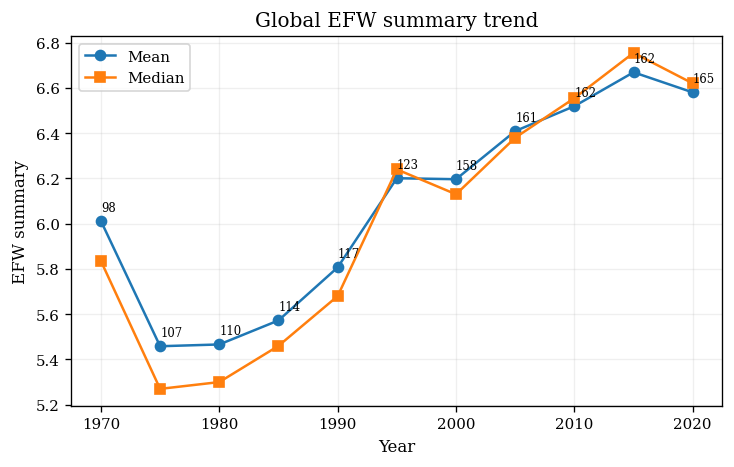

In [3]:
trend = (
    panel.groupby("year")["efw_summary"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
)
display(trend.style.set_caption("Global EFW trend summary"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trend["year"], trend["mean"], marker="o", label="Mean")
ax.plot(trend["year"], trend["median"], marker="s", label="Median")
for _, row in trend.iterrows():
    ax.annotate(int(row["n"]), (row["year"], row["mean"]), textcoords="offset points", xytext=(0, 6), fontsize=7)
ax.set_title("Global EFW summary trend")
ax.set_xlabel("Year")
ax.set_ylabel("EFW summary")
ax.legend()

display(fig)
savefig(fig, OUTPUT_DIR / "figures" / "trends" / "efw_summary_trend")
plt.close(fig)

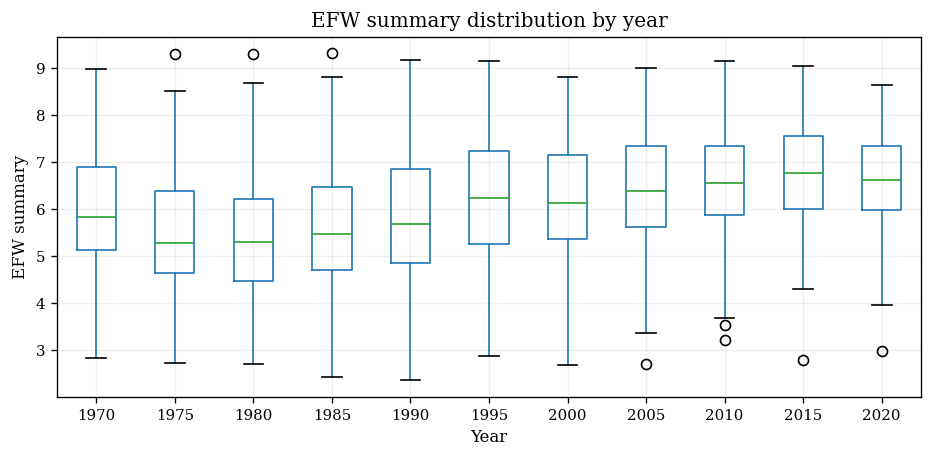

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
panel.boxplot(column="efw_summary", by="year", ax=ax)
ax.set_title("EFW summary distribution by year")
ax.set_xlabel("Year")
ax.set_ylabel("EFW summary")
fig.suptitle("")

display(fig)
savefig(fig, OUTPUT_DIR / "figures" / "trends" / "efw_summary_boxplot")
plt.close(fig)

In [5]:
rank_dir = OUTPUT_DIR / "tables"
rank_dir.mkdir(parents=True, exist_ok=True)
for year in QUINQUENNIAL_YEARS:
    subset = panel[panel["year"] == year][["iso3c", "country_name", "efw_summary"]].dropna()
    if subset.empty:
        continue
    ranked = subset.sort_values("efw_summary", ascending=False).reset_index(drop=True)
    ranked["rank"] = ranked.index + 1
    top_bottom = pd.concat([ranked.head(10), ranked.tail(10)])
    top_bottom.to_csv(rank_dir / f"global_rankings_{year}.csv", index=False)
    display(top_bottom.style.set_caption(f"Top/bottom EFW rankings, {year}"))

,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",8.970000,1
1,CAN,Canada,8.140000,2
2,USA,United States,8.110000,3
3,AUS,Australia,8.100000,4
4,DEU,Germany,8.090000,5
5,BRB,Barbados,8.050000,6
6,BEL,Belgium,8.000000,7
7,CRI,Costa Rica,7.980000,8
8,CHE,Switzerland,7.980000,9
9,LUX,Luxembourg,7.970000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.300000,1
1,LUX,Luxembourg,8.510000,2
2,USA,United States,8.200000,3
3,CAN,Canada,8.020000,4
4,DEU,Germany,7.890000,5
5,CHE,Switzerland,7.800000,6
6,NLD,Netherlands,7.640000,7
7,JPN,Japan,7.480000,8
8,AUS,Australia,7.470000,9
9,SGP,Singapore,7.470000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.290000,1
1,LUX,Luxembourg,8.690000,2
2,USA,United States,8.490000,3
3,CHE,Switzerland,8.420000,4
4,CAN,Canada,8.260000,5
5,DEU,Germany,8.120000,6
6,AUS,Australia,7.920000,7
7,NLD,Netherlands,7.890000,8
8,BEL,Belgium,7.840000,9
9,SGP,Singapore,7.680000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.320000,1
1,LUX,Luxembourg,8.820000,2
2,CHE,Switzerland,8.770000,3
3,USA,United States,8.640000,4
4,GBR,United Kingdom,8.490000,5
5,CAN,Canada,8.350000,6
6,AUS,Australia,8.250000,7
7,DEU,Germany,8.150000,8
8,SGP,Singapore,8.080000,9
9,JPN,Japan,7.980000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.180000,1
1,CHE,Switzerland,8.800000,2
2,USA,United States,8.740000,3
3,SGP,Singapore,8.530000,4
4,GBR,United Kingdom,8.490000,5
5,AUS,Australia,8.420000,6
6,DEU,Germany,8.340000,7
7,CAN,Canada,8.330000,8
8,JPN,Japan,8.290000,9
9,NZL,New Zealand,8.250000,10


...

,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",8.810000,1
1,NZL,New Zealand,8.760000,2
2,CHE,Switzerland,8.740000,3
3,USA,United States,8.730000,4
4,GBR,United Kingdom,8.630000,5
5,SGP,Singapore,8.610000,6
6,AUS,Australia,8.360000,7
7,DNK,Denmark,8.240000,8
8,CAN,Canada,8.240000,9
9,IRL,Ireland,8.170000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.000000,1
1,SGP,Singapore,8.760000,2
2,NZL,New Zealand,8.600000,3
3,USA,United States,8.450000,4
4,GBR,United Kingdom,8.350000,5
5,CHE,Switzerland,8.330000,6
6,IRL,Ireland,8.240000,7
7,AUS,Australia,8.220000,8
8,CAN,Canada,8.210000,9
9,ISL,Iceland,8.100000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.160000,1
1,SGP,Singapore,8.640000,2
2,NZL,New Zealand,8.430000,3
3,CHE,Switzerland,8.390000,4
4,AUS,Australia,8.150000,5
5,USA,United States,8.140000,6
6,GBR,United Kingdom,8.090000,7
7,MUS,Mauritius,8.020000,8
8,EST,Estonia,8.010000,9
9,CHL,Chile,8.010000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",9.040000,1
1,SGP,Singapore,8.750000,2
2,NZL,New Zealand,8.730000,3
3,USA,United States,8.320000,4
4,CHE,Switzerland,8.320000,5
5,IRL,Ireland,8.310000,6
6,AUS,Australia,8.270000,7
7,GBR,United Kingdom,8.260000,8
8,DEU,Germany,8.130000,9
9,CAN,Canada,8.100000,10


,iso3c,country_name,efw_summary,rank
0,HKG,"Hong Kong SAR, China",8.640000,1
1,SGP,Singapore,8.440000,2
2,NZL,New Zealand,8.370000,3
3,CHE,Switzerland,8.210000,4
4,AUS,Australia,8.090000,5
5,USA,United States,8.020000,6
6,DNK,Denmark,7.970000,7
7,IRL,Ireland,7.900000,8
8,EST,Estonia,7.860000,9
9,JPN,Japan,7.830000,10


## Interpretation
The global trend plot shows mean EFW rising from 6.01 in 1970 to 6.58 in 2020,
while the median increases from 5.84 to 6.62 as coverage expands from 98 to
165 countries. Boxplots reveal persistent dispersion around these averages,
and the rankings highlight which countries consistently lead or lag,
providing context for interpreting subsequent regional and component analyses.